# Visualisasi Hasil Eksperimen
**Baseline vs FP-Augmentation | Target: r_dicho & b_dicho**

## 0. Setup & Konfigurasi

In [16]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# KONFIGURASI — sesuaikan path dan parameter
# ─────────────────────────────────────────────
RESULTS_ROOT = {           # root folder masing-masing pendekatan
    'Baseline' : 'Results_Baseline_Holdout',
    'FP-Augmented': 'Results_With_FP_Holdout',
}

TARGETS          = ['r_dicho', 'b_dicho']
TARGET_LABELS    = {'r_dicho': 'Return (r_dicho)', 'b_dicho': 'Beta (b_dicho)'}

RANDOM_STATES    = [42]
SCALING_METHODS  = ['MinMax', 'Standard']

# Subfolder di dalam root yang menyimpan results_metrics.csv
# Struktur: {root}/{target}/{random_state}_{scaling}/results_metrics.csv
RESULT_SUBDIR    = '3_Results'   # kosongkan ('') jika langsung di root

# Metrik yang divisualisasikan
METRIC_COLS = ['accuracy_mean', 'precision_mean', 'recall_mean', 'f1_mean',
               'auc_roc_mean', 'aupr_mean', 'specificity_mean', 'sensitivity_mean', 'mcc_mean']
METRIC_LABELS = {
    'accuracy_mean'   : 'Accuracy',
    'precision_mean'  : 'Precision',
    'recall_mean'     : 'Recall',
    'f1_mean'         : 'F1 Score',
    'auc_roc_mean'    : 'AUC-ROC',
    'aupr_mean'       : 'AUPR',
    'specificity_mean': 'Specificity',
    'sensitivity_mean': 'Sensitivity',
    'mcc_mean'        : 'MCC',
}

ALGORITHMS = ['DT', 'LR', 'RF', 'SVM', 'HGB']
ALGO_COLORS = {
    'DT' : '#4C72B0',
    'LR' : '#DD8452',
    'RF' : '#55A868',
    'SVM': '#C44E52',
    'HGB': '#8172B2',
}

mpl.rcParams.update({
    'font.family'     : 'serif',
    'font.serif'      : ['Times New Roman'],
    'font.size'       : 11,
    'axes.titlesize'  : 13,
    'axes.titleweight': 'bold',
    'axes.labelsize'  : 11,
    'legend.fontsize' : 10,
    'xtick.labelsize' : 10,
    'ytick.labelsize' : 10,
})

OUTPUT_DIR = 'Visualisasi'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Setup selesai.')

Setup selesai.


## 1. Load & Aggregate Semua results_metrics.csv

In [17]:
def load_all_results(results_root, targets, random_states, scaling_methods, result_subdir=''):
    """
    Baca semua results_metrics.csv dari struktur folder:
    {approach_root}/{result_subdir}/{target}/{rs}_{scaling}/results_metrics.csv
    
    Return: dict { approach -> { target -> DataFrame (avg across rs & scaling) } }
    """
    all_data = {}   # approach -> target -> list of df

    for approach, root in results_root.items():
        all_data[approach] = {t: [] for t in targets}

        for target in targets:
            for rs in random_states:
                for scaling in scaling_methods:
                    parts = [root]
                    if result_subdir:
                        parts.append(result_subdir)
                    parts += [target, f'{rs}_{scaling}', 'results_metrics.csv']
                    path = os.path.join(*parts)

                    if os.path.exists(path):
                        df = pd.read_csv(path, index_col='Algorithm')
                        # Tandai dari run mana
                        df['_rs']      = rs
                        df['_scaling'] = scaling
                        all_data[approach][target].append(df)
                    else:
                        print(f'[SKIP] Tidak ditemukan: {path}')

    # Aggregate: rata-rata semua run per approach per target
    aggregated = {}
    for approach in results_root:
        aggregated[approach] = {}
        for target in targets:
            frames = all_data[approach][target]
            if not frames:
                print(f'[WARN] Tidak ada data untuk {approach} - {target}')
                continue
            combined = pd.concat(frames)
            # Ambil kolom numerik saja, group by Algorithm, rata-rata
            num_cols = combined.select_dtypes(include='number').columns.tolist()
            meta_cols = ['_rs']
            num_cols = [c for c in num_cols if c not in meta_cols]
            aggregated[approach][target] = (
                combined[num_cols]
                .groupby(combined.index)
                .mean()
                .loc[[a for a in ALGORITHMS if a in combined.index.unique()]]
            )

    return aggregated


data = load_all_results(
    RESULTS_ROOT, TARGETS, RANDOM_STATES, SCALING_METHODS, RESULT_SUBDIR
)

# Preview
for approach, targets_dict in data.items():
    for target, df in targets_dict.items():
        print(f'\n=== {approach} | {target} ===')
        display(df[METRIC_COLS] if all(c in df.columns for c in METRIC_COLS) else df)


=== Baseline | r_dicho ===


,accuracy_mean,precision_mean,recall_mean,f1_mean,auc_roc_mean,aupr_mean,specificity_mean,sensitivity_mean,mcc_mean
Algorithm,,,,,,,,,
DT,94.360,93.715,97.62,95.630,93.200,96.420,88.78,97.62,87.845
LR,94.545,97.235,94.05,95.610,98.450,98.595,95.41,94.05,88.530
RF,96.805,96.775,98.21,97.490,99.705,99.825,94.39,98.21,93.115
SVM,95.300,97.850,94.64,96.215,98.730,98.890,96.43,94.64,90.105
HGB,96.240,94.380,100.00,97.110,99.730,99.840,89.80,100.00,92.060



=== Baseline | b_dicho ===


,accuracy_mean,precision_mean,recall_mean,f1_mean,auc_roc_mean,aupr_mean,specificity_mean,sensitivity_mean,mcc_mean
Algorithm,,,,,,,,,
DT,99.250,99.450,99.450,99.450,99.14,99.640,98.820,99.450,98.270
LR,54.700,76.825,47.790,58.845,69.00,79.375,69.415,47.790,16.245
RF,99.250,99.450,99.450,99.450,99.41,99.720,98.820,99.450,98.270
SVM,51.505,74.240,43.645,54.900,64.99,77.245,68.235,43.645,11.245
HGB,99.620,99.450,100.000,99.720,100.00,100.000,98.820,100.000,99.140



=== FP-Augmented | r_dicho ===


,accuracy_mean,precision_mean,recall_mean,f1_mean,auc_roc_mean,aupr_mean,specificity_mean,sensitivity_mean,mcc_mean
Algorithm,,,,,,,,,
DT,93.795,92.680,97.915,95.225,92.325,95.955,86.735,97.915,86.670
LR,93.980,96.640,93.750,95.165,98.365,98.500,94.390,93.750,87.305
RF,97.180,97.070,98.510,97.785,99.800,99.880,94.900,98.510,93.930
SVM,94.925,95.445,96.725,96.020,98.380,98.665,91.835,96.725,89.245
HGB,96.240,94.380,100.000,97.110,99.755,99.855,89.800,100.000,92.060



=== FP-Augmented | b_dicho ===


,accuracy_mean,precision_mean,recall_mean,f1_mean,auc_roc_mean,aupr_mean,specificity_mean,sensitivity_mean,mcc_mean
Algorithm,,,,,,,,,
DT,99.435,99.450,99.725,99.585,99.275,99.685,98.820,99.725,98.705
LR,67.105,82.200,64.090,70.940,78.490,86.260,73.530,64.090,36.625
RF,99.435,99.450,99.725,99.585,99.410,99.725,98.820,99.725,98.705
SVM,68.235,82.465,66.575,72.865,78.280,87.165,71.765,66.575,37.285
HGB,99.620,99.450,100.000,99.720,100.000,100.000,98.820,100.000,99.140


## 2. Helper — Tabel Ringkasan

In [18]:
def make_summary_table(data, target, metrics=None):
    """
    Buat tabel perbandingan Baseline vs FP-Augmented untuk satu target.
    MultiIndex kolom: (Approach, Metric)
    """
    if metrics is None:
        metrics = METRIC_COLS

    frames = {}
    for approach, targets_dict in data.items():
        if target not in targets_dict:
            continue
        df = targets_dict[target]
        avail = [m for m in metrics if m in df.columns]
        frames[approach] = df[avail].rename(columns=METRIC_LABELS)

    if not frames:
        return pd.DataFrame()

    combined = pd.concat(frames, axis=1)
    return combined


for target in TARGETS:
    print(f'\n{'='*60}')
    print(f'  Ringkasan: {TARGET_LABELS.get(target, target)}')
    print(f'{'='*60}')
    tbl = make_summary_table(data, target)
    if not tbl.empty:
        display(tbl.round(2))


  Ringkasan: Return (r_dicho)


Baseline                                                        \
          Accuracy Precision  Recall F1 Score AUC-ROC   AUPR Specificity   
Algorithm                                                                  
DT           94.36     93.72   97.62    95.63   93.20  96.42       88.78   
LR           94.54     97.24   94.05    95.61   98.45  98.60       95.41   
RF           96.80     96.78   98.21    97.49   99.70  99.82       94.39   
SVM          95.30     97.85   94.64    96.22   98.73  98.89       96.43   
HGB          96.24     94.38  100.00    97.11   99.73  99.84       89.80   

                             FP-Augmented                                     \
          Sensitivity    MCC     Accuracy Precision  Recall F1 Score AUC-ROC   
Algorithm                                                                      
DT              97.62  87.84        93.80     92.68   97.92    95.22   92.32   
LR              94.05  88.53        93.98     96.64   93.75    95.16   98.36   
RF              98.21  93.12        97.18     97.07   98.51    97.78   99.80   
SVM             94.64  90.10        94.92     95.44   96.72    96.02   98.38   
HGB            100.00  92.06        96.24     94.38  100.00    97.11   99.76   

                                                 
            AUPR Specificity Sensitivity    MCC  
Algorithm                                        
DT         95.96       86.74       97.92  86.67  
LR         98.50       94.39       93.75  87.30  
RF         99.88       94.90       98.51  93.93  
SVM        98.66       91.84       96.72  89.24  
HGB        99.86       89.80      100.00  92.06


  Ringkasan: Beta (b_dicho)


Baseline                                                         \
          Accuracy Precision  Recall F1 Score AUC-ROC    AUPR Specificity   
Algorithm                                                                   
DT           99.25     99.45   99.45    99.45   99.14   99.64       98.82   
LR           54.70     76.82   47.79    58.84   69.00   79.38       69.41   
RF           99.25     99.45   99.45    99.45   99.41   99.72       98.82   
SVM          51.50     74.24   43.64    54.90   64.99   77.24       68.24   
HGB          99.62     99.45  100.00    99.72  100.00  100.00       98.82   

                             FP-Augmented                                     \
          Sensitivity    MCC     Accuracy Precision  Recall F1 Score AUC-ROC   
Algorithm                                                                      
DT              99.45  98.27        99.44     99.45   99.72    99.58   99.28   
LR              47.79  16.24        67.10     82.20   64.09    70.94   78.49   
RF              99.45  98.27        99.44     99.45   99.72    99.58   99.41   
SVM             43.64  11.24        68.24     82.46   66.58    72.87   78.28   
HGB            100.00  99.14        99.62     99.45  100.00    99.72  100.00   

                                                  
             AUPR Specificity Sensitivity    MCC  
Algorithm                                         
DT          99.68       98.82       99.72  98.70  
LR          86.26       73.53       64.09  36.62  
RF          99.72       98.82       99.72  98.70  
SVM         87.16       71.76       66.58  37.29  
HGB        100.00       98.82      100.00  99.14

## 3. Grouped Bar Chart — per Target, semua Metrik

Disimpan → Visualisasi\grouped_bar_r_dicho.png


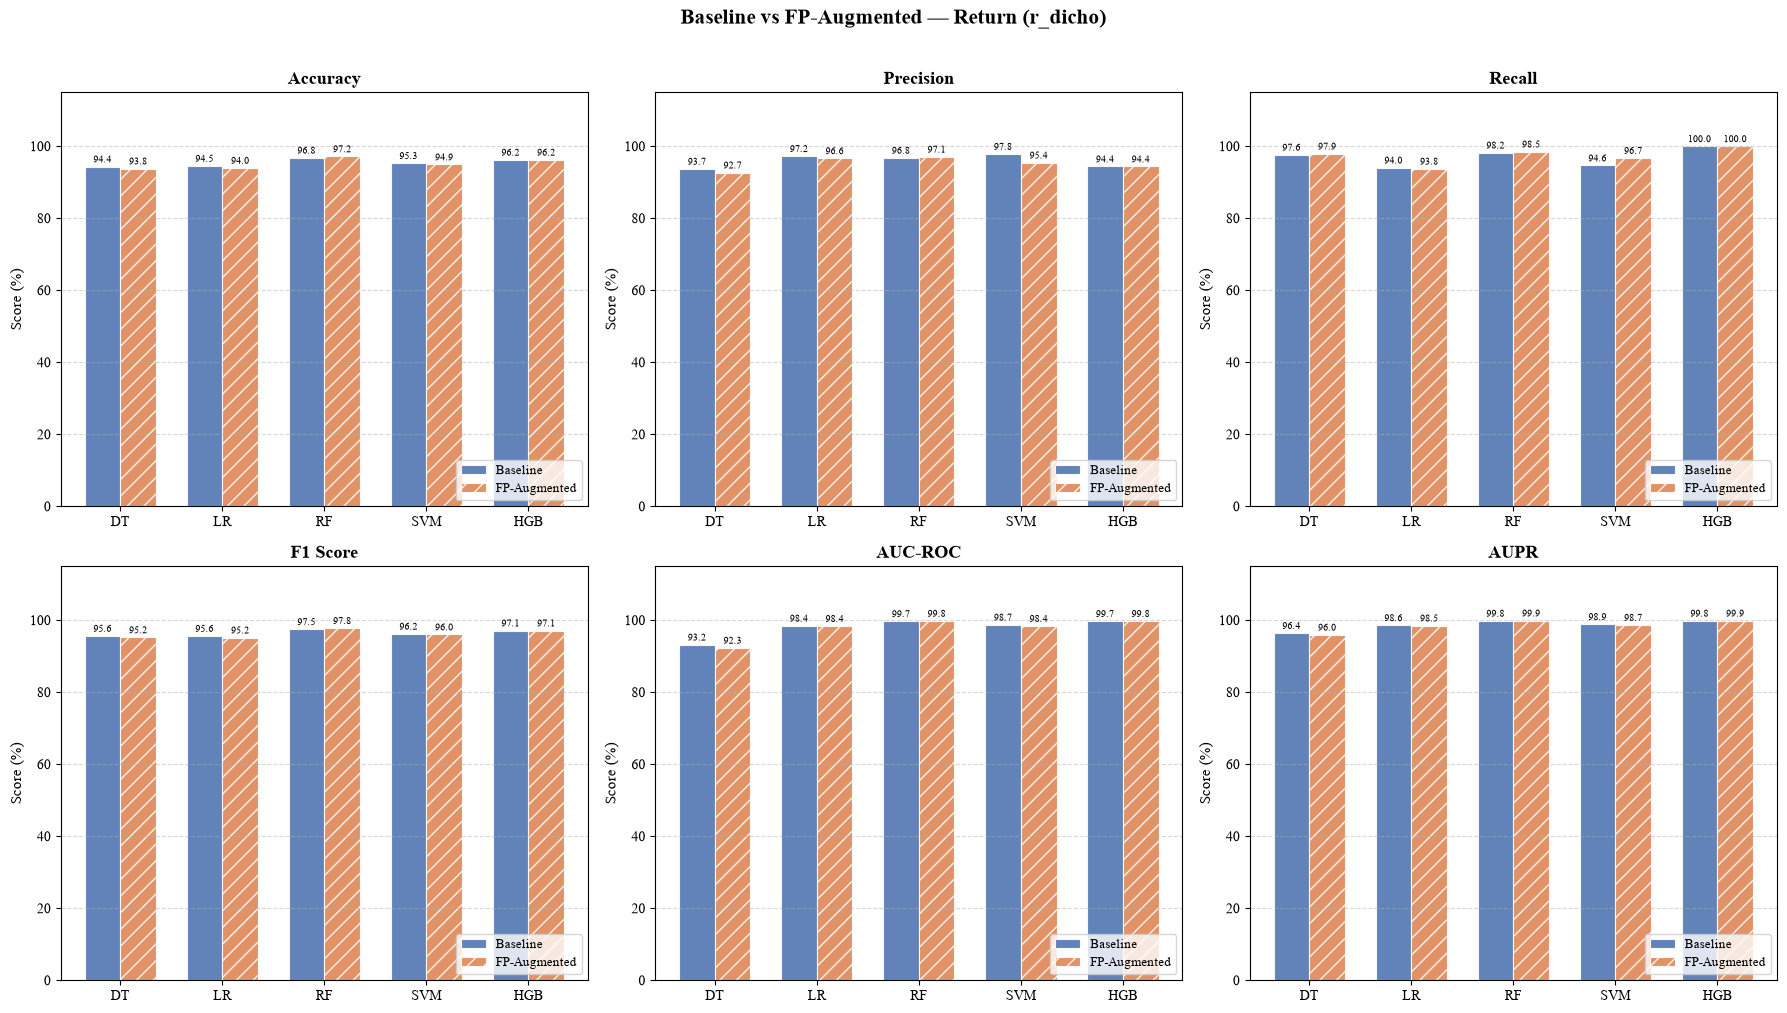

Disimpan → Visualisasi\grouped_bar_b_dicho.png


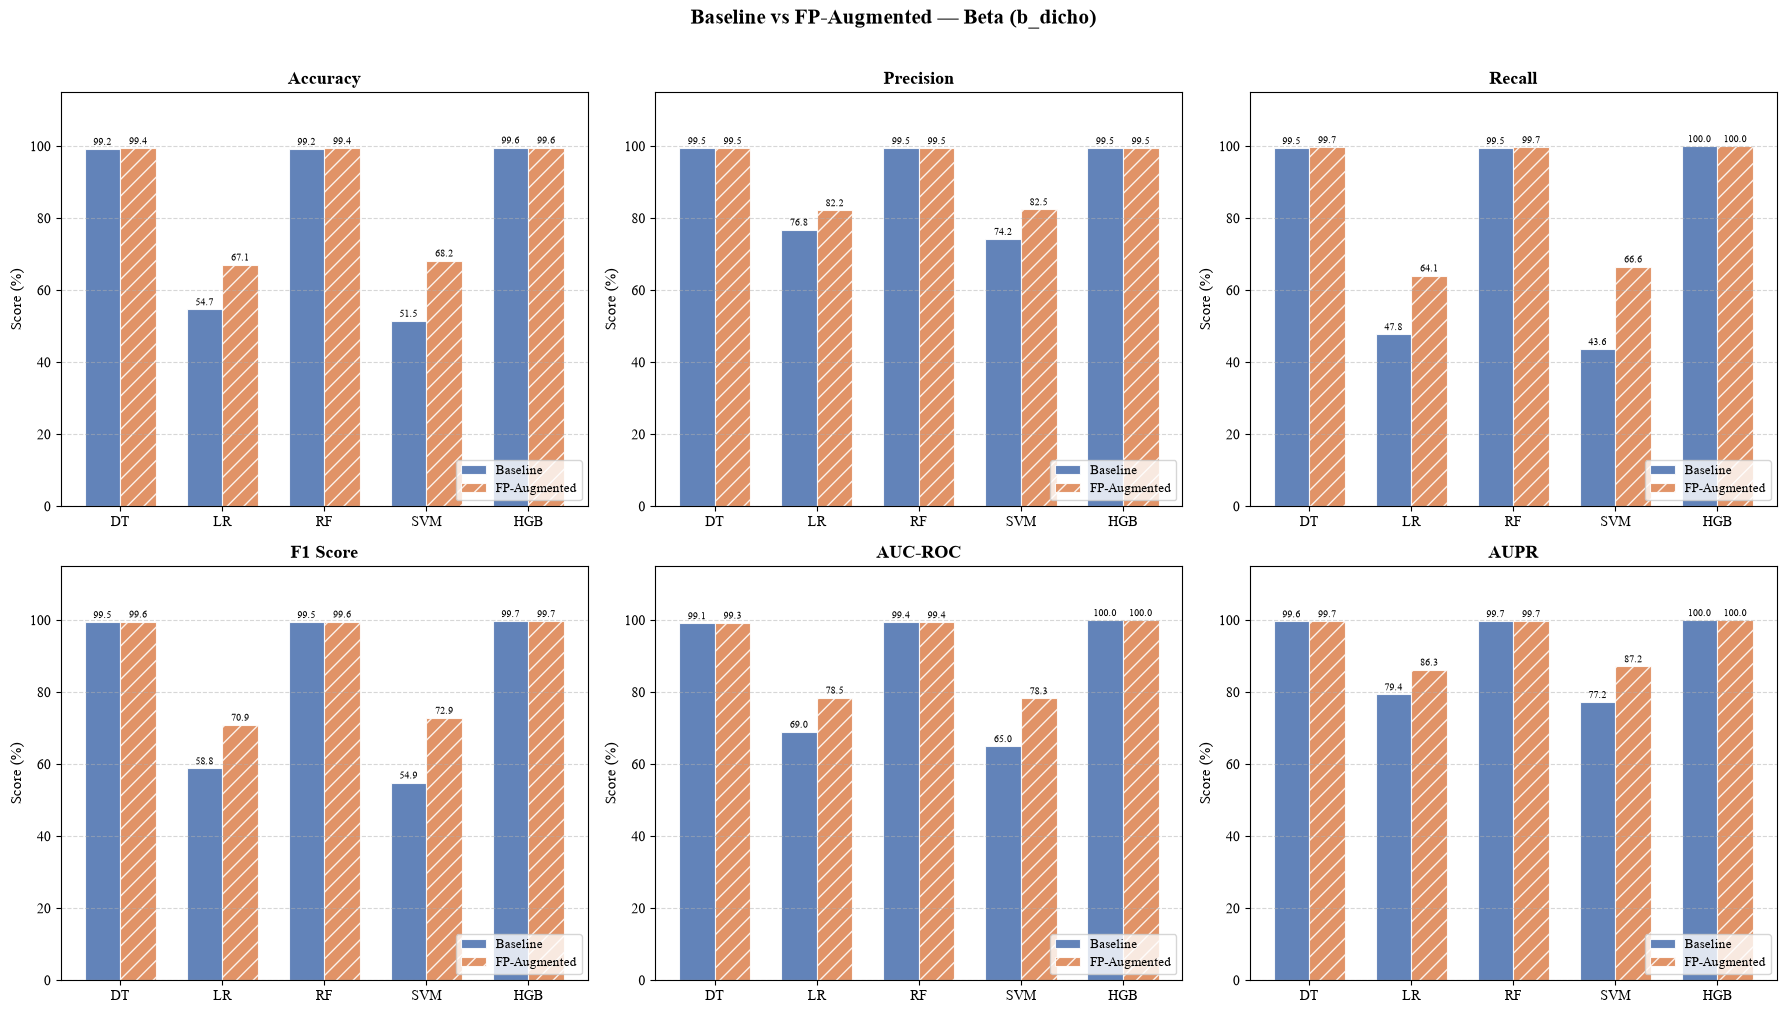

In [19]:
def plot_grouped_bar(data, target, metrics=None, save=True):
    """
    Bar chart: x = algoritma, grup warna = approach (Baseline / FP-Augmented)
    Satu subplot per metrik.
    """
    if metrics is None:
        metrics = ['accuracy_mean', 'precision_mean', 'recall_mean', 'f1_mean',
                   'auc_roc_mean', 'aupr_mean']

    approaches = list(data.keys())
    n_metrics  = len(metrics)
    ncols      = 3
    nrows      = int(np.ceil(n_metrics / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = axes.flatten()

    approach_colors = {'Baseline': '#4C72B0', 'FP-Augmented': '#DD8452'}
    approach_hatch  = {'Baseline': '',        'FP-Augmented': '//'}

    x         = np.arange(len(ALGORITHMS))
    bar_width = 0.35

    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        metric_label = METRIC_LABELS.get(metric, metric)

        for i, approach in enumerate(approaches):
            if target not in data[approach]:
                continue
            df = data[approach][target]
            vals = []
            for algo in ALGORITHMS:
                if algo in df.index and metric in df.columns:
                    vals.append(df.loc[algo, metric])
                else:
                    vals.append(0)

            offset = (i - len(approaches) / 2) * bar_width + bar_width / 2
            bars = ax.bar(
                x + offset, vals, bar_width,
                label=approach,
                color=approach_colors.get(approach, f'C{i}'),
                hatch=approach_hatch.get(approach, ''),
                edgecolor='white', linewidth=0.8, alpha=0.88
            )
            # Nilai di atas bar
            for bar, v in zip(bars, vals):
                if v > 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.5,
                        f'{v:.1f}',
                        ha='center', va='bottom', fontsize=7.5, rotation=0
                    )

        ax.set_title(metric_label)
        ax.set_xticks(x)
        ax.set_xticklabels(ALGORITHMS)
        ax.set_ylabel('Score (%)')
        ax.set_ylim(0, 115)
        ax.legend(loc='lower right', fontsize=9)
        ax.grid(axis='y', linestyle='--', alpha=0.5)

    # Sembunyikan subplot kosong
    for idx in range(n_metrics, len(axes)):
        axes[idx].set_visible(False)

    fig.suptitle(
        f'Baseline vs FP-Augmented — {TARGET_LABELS.get(target, target)}',
        fontsize=15, fontweight='bold', y=1.01
    )
    plt.tight_layout()

    if save:
        fname = os.path.join(OUTPUT_DIR, f'grouped_bar_{target}.png')
        plt.savefig(fname, dpi=200, bbox_inches='tight')
        print(f'Disimpan → {fname}')
    plt.show()


for target in TARGETS:
    plot_grouped_bar(data, target)

## 4. Heatmap — Semua Algoritma × Semua Metrik

Disimpan → Visualisasi\heatmap_r_dicho.png


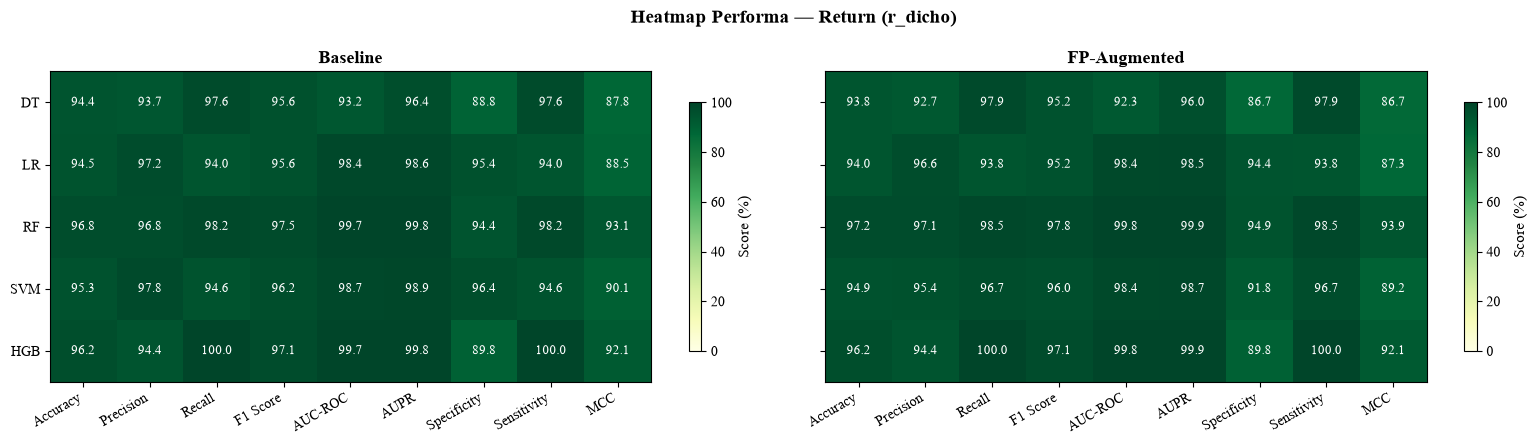

Disimpan → Visualisasi\heatmap_b_dicho.png


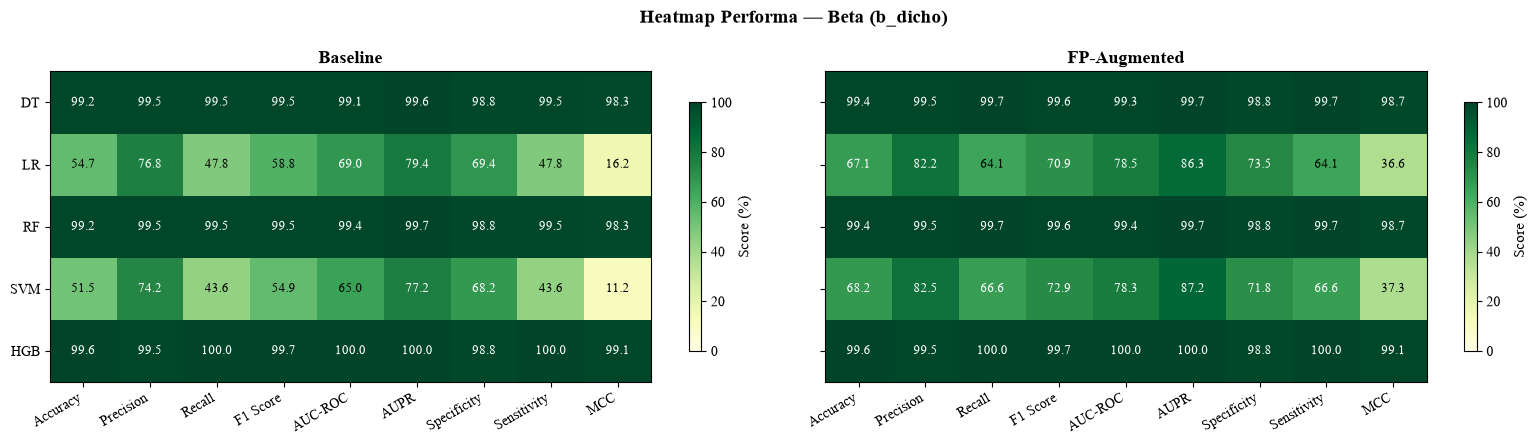

In [20]:
def plot_heatmap(data, target, metrics=None, save=True):
    """
    Heatmap: baris = algoritma, kolom = metrik.
    Dua subplot berdampingan: Baseline | FP-Augmented.
    """
    if metrics is None:
        metrics = METRIC_COLS

    approaches = [a for a in data if target in data[a]]
    n = len(approaches)
    fig, axes = plt.subplots(1, n, figsize=(8 * n, 4.5), sharey=True)
    if n == 1:
        axes = [axes]

    for ax, approach in zip(axes, approaches):
        df = data[approach][target]
        avail_metrics = [m for m in metrics if m in df.columns]
        plot_df = df.loc[
            [a for a in ALGORITHMS if a in df.index], avail_metrics
        ].rename(columns=METRIC_LABELS)

        im = ax.imshow(plot_df.values.astype(float), cmap='YlGn',
                       aspect='auto', vmin=0, vmax=100)

        ax.set_xticks(range(len(plot_df.columns)))
        ax.set_xticklabels(plot_df.columns, rotation=30, ha='right')
        ax.set_yticks(range(len(plot_df.index)))
        ax.set_yticklabels(plot_df.index)
        ax.set_title(approach, fontsize=13)

        # Nilai di dalam cell
        for r in range(plot_df.shape[0]):
            for c in range(plot_df.shape[1]):
                v = plot_df.values[r, c]
                color = 'white' if float(v) > 65 else 'black'
                ax.text(c, r, f'{float(v):.1f}', ha='center', va='center',
                        fontsize=9, color=color)

        plt.colorbar(im, ax=ax, shrink=0.8, label='Score (%)')

    fig.suptitle(
        f'Heatmap Performa — {TARGET_LABELS.get(target, target)}',
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout()

    if save:
        fname = os.path.join(OUTPUT_DIR, f'heatmap_{target}.png')
        plt.savefig(fname, dpi=200, bbox_inches='tight')
        print(f'Disimpan → {fname}')
    plt.show()


for target in TARGETS:
    plot_heatmap(data, target)

## 7. Export Tabel Lengkap ke CSV

In [23]:
for target in TARGETS:
    tbl = make_summary_table(data, target)
    if tbl.empty:
        continue
    path = os.path.join(OUTPUT_DIR, f'summary_{target}.csv')
    tbl.round(2).to_csv(path)
    print(f'Tabel disimpan → {path}')

print('\nSelesai. Semua output ada di folder:', OUTPUT_DIR)

Tabel disimpan → Visualisasi\summary_r_dicho.csv
Tabel disimpan → Visualisasi\summary_b_dicho.csv

Selesai. Semua output ada di folder: Visualisasi
